# Tutorial 1: mock TCGA scVI embeddings and TME subtype prediction

In [1]:
import sys
sys.path.append('../src')

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from tumor_subtyper import (
    compute_batch_mixing_metrics,
    generate_mock_data,
    get_batch_corrected_embedding,
    get_embedding_scvi,
    load_classifier,
    load_expression_data,
    load_new_cohort,
    normalize_expression,
    predict_subtypes,
    train_pipeline,
)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in {"tutorial", "tutorials"} else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "TCGA"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "mock_tutorial"

2026-07-15 15:42:27.522028: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-15 15:42:27.573616: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
DATA_DIR

PosixPath('/gpfs/commons/groups/compbio/projects/ao_projects/tumor_subtyper/data/TCGA')

## Load TCGA data

In [ ]:
import pandas as pd

temp = pd.read_table("../data/TCGA/TCGA_LUAD_counts_LUAD.tsv")

In [5]:
dataset = load_expression_data(DATA_DIR)

print(f"Expression matrix: {dataset.expression.shape[0]} samples x {dataset.expression.shape[1]} genes")
display(pd.crosstab(dataset.cohorts, dataset.labels))
display(dataset.expression.iloc[:5, :8])

ValueError: Sample IDs occur in multiple cohorts: ['ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.13', 'ENSG00000000457.14', 'ENSG00000000460.17']

### Raw-expression PCA and UMAP, colored by batch

We apply the same library-size plus `log1p` normalization used by the default pipeline, select the 100 most variable mock genes, and standardize them for visualization. These projections are descriptive only and are not classifier inputs.

/nfs/home/aoku/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


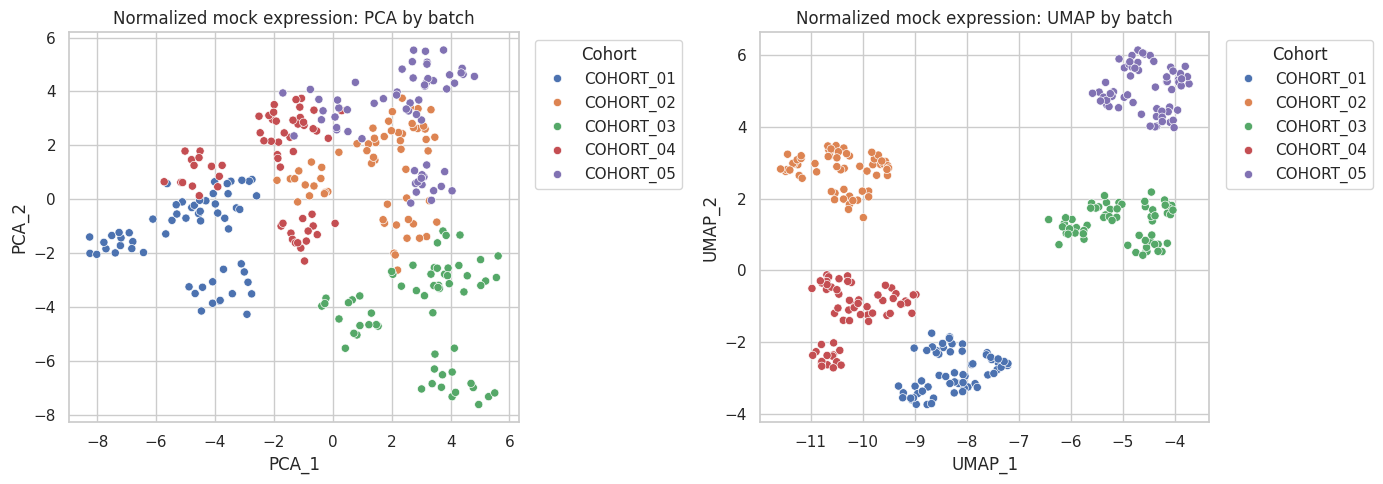

In [4]:
normalized_expression = normalize_expression(dataset.expression)
variable_genes = normalized_expression.var(axis=0).nlargest(100).index
raw_scaled = StandardScaler().fit_transform(normalized_expression.loc[:, variable_genes])

raw_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(raw_scaled)
raw_umap = umap.UMAP(
    n_neighbors=20, min_dist=0.25, metric="euclidean", random_state=RANDOM_STATE
).fit_transform(raw_scaled)

raw_projection = pd.DataFrame(
    {
        "PCA_1": raw_pca[:, 0],
        "PCA_2": raw_pca[:, 1],
        "UMAP_1": raw_umap[:, 0],
        "UMAP_2": raw_umap[:, 1],
        "batch": dataset.cohorts.to_numpy(),
    },
    index=dataset.expression.index,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=raw_projection, x="PCA_1", y="PCA_2", hue="batch", s=35, ax=axes[0])
sns.scatterplot(data=raw_projection, x="UMAP_1", y="UMAP_2", hue="batch", s=35, ax=axes[1])
axes[0].set_title("Normalized mock expression: PCA by batch")
axes[1].set_title("Normalized mock expression: UMAP by batch")
for axis in axes:
    axis.legend(title="Cohort", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 2. Train scVI and inspect its transformed embeddings

The pipeline treats samples as AnnData observations and cohort as scVI's batch variable. **Raw synthetic counts** are passed to scVI; the normalized matrix above is used only for the exploratory PCA/UMAP. Training has a 300-epoch ceiling with early stopping (patience 30). The pipeline saves the reference model, manifest, cross-validation results, and final XGBoost classifier.

In [5]:
training = train_pipeline(
    DATA_DIR,
    ARTIFACT_DIR,
    model_kind="random_forest",
    n_splits=5,
    n_latent=20,
    max_epochs=300,
    random_state=RANDOM_STATE,
    normalize=False,
    classifier_params={"n_estimators": 150},
)
train_embeddings = training.embeddings
display(training.classifier_result.fold_metrics)
display(train_embeddings.head())
print("scVI embedding shape:", train_embeddings.shape)

[rank: 0] Seed set to 42
/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /nfs/home/aoku/.local/lib/python3.10/site-packag ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /nfs/home/aoku/.local/lib/python3.10/site-packag ...
/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and tree

Training:   0%|          | 0/300 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


,fold,accuracy,balanced_accuracy,macro_f1
0,1,1.0,1.0,1.0
1,2,1.0,1.0,1.0
2,3,1.0,1.0,1.0
3,4,1.0,1.0,1.0
4,5,1.0,1.0,1.0


,scVI_0,scVI_1,scVI_2,scVI_3,scVI_4,scVI_5,scVI_6,scVI_7,scVI_8,scVI_9,scVI_10,scVI_11,scVI_12,scVI_13,scVI_14,scVI_15,scVI_16,scVI_17,scVI_18,scVI_19
sample_id,,,,,,,,,,,,,,,,,,,,
MOCK_COHORT_01_0001,0.583909,0.295208,1.162585,-0.321112,0.306569,-0.418504,0.148100,-0.668560,0.053793,1.244033,-0.042395,-0.499808,-0.959599,-0.309691,-0.887558,0.259007,-1.482552,0.864422,-0.773440,0.161577
MOCK_COHORT_01_0002,0.607356,0.215341,-0.659309,-0.809307,0.681898,-0.339319,0.232952,-0.197315,0.126176,0.416631,-1.102635,0.855665,-1.782678,-0.064370,0.364002,-0.118885,0.818464,-0.415672,0.857569,0.125303
MOCK_COHORT_01_0003,0.244631,0.001716,-0.123052,-1.038491,0.842125,-0.524709,0.291107,-0.475702,0.357342,0.593279,-1.692816,0.908687,-1.891973,-0.067286,0.753597,-0.776817,0.231154,0.490574,0.694031,-0.181940
MOCK_COHORT_01_0004,0.556335,0.529551,1.289697,-0.390766,0.447343,-0.221245,0.247226,-0.862063,-0.160239,0.910391,0.037798,0.085533,-1.338076,-0.442553,-0.484492,-0.224205,-1.816551,1.048923,-0.816741,-0.113988
MOCK_COHORT_01_0005,0.722175,0.072931,-0.540510,0.013374,0.226869,-0.477733,0.527402,-0.160576,-0.162067,0.598387,-0.559971,0.729653,0.544576,0.221310,0.335069,1.233784,-1.459349,-0.128196,-1.141309,-0.712811


scVI embedding shape: (300, 20)


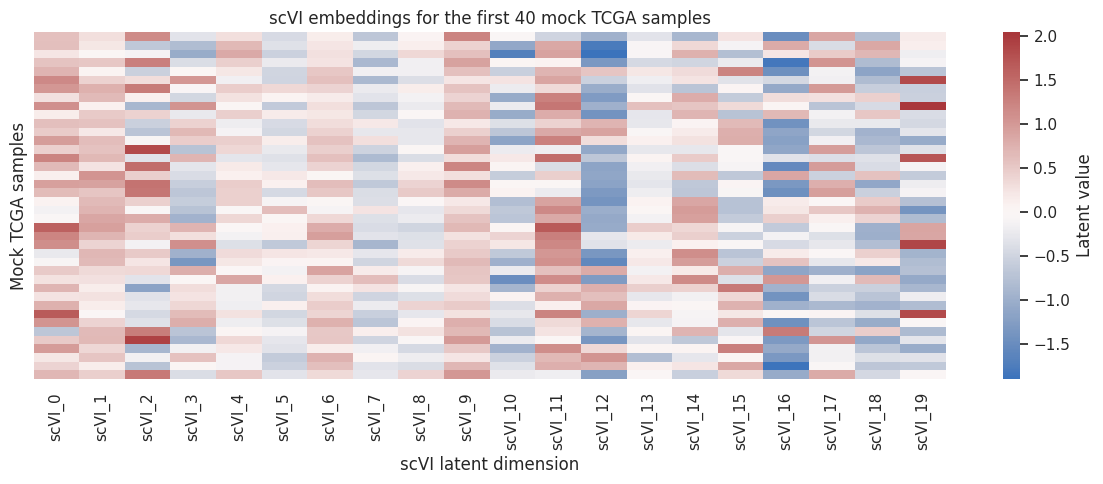

In [6]:
plt.figure(figsize=(12, 5))
sns.heatmap(
    train_embeddings.iloc[:40],
    cmap="vlag",
    center=0,
    yticklabels=False,
    cbar_kws={"label": "Latent value"},
)
plt.title("scVI embeddings for the first 40 mock TCGA samples")
plt.xlabel("scVI latent dimension")
plt.ylabel("Mock TCGA samples")
plt.tight_layout()
plt.show()

### Quantify scVI batch mixing with silhouette and LISI

UMAP is qualitative, so we also calculate metrics in the full latent space. A batch silhouette near zero (and silhouette-mixing score near one) indicates less global cohort separation. Higher batch LISI indicates more locally diverse cohort neighborhoods; normalized LISI ranges from zero to one.

In [7]:
scvi_batch_metrics = compute_batch_mixing_metrics(
    train_embeddings, dataset.cohorts, n_neighbors=30
)
display(scvi_batch_metrics.to_frame())

,value
batch_silhouette,0.069762
batch_silhouette_mixing,0.930238
mean_batch_lisi,3.226589
normalized_batch_lisi,0.556647
lisi_neighbors,30.000000


## 3–4. UMAP of scVI embeddings by batch and synthetic TME subtype

A single UMAP fit is reused in both panels, so only the coloring changes. Effective correction should reduce separation driven purely by mock cohort while retaining shared subtype structure.

/nfs/home/aoku/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


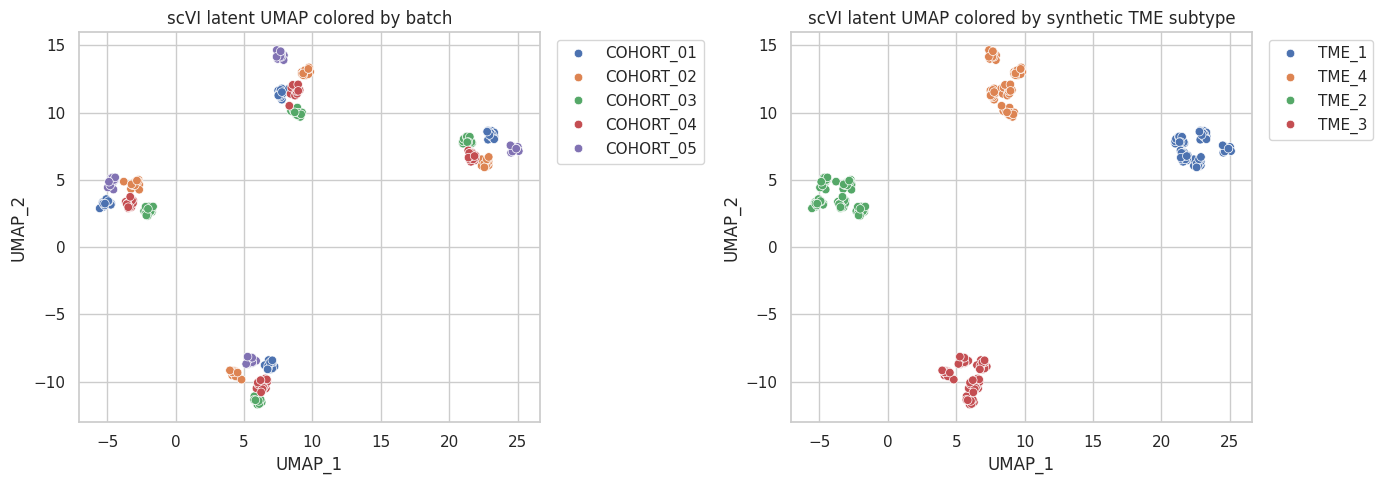

In [8]:
latent_umap_model = umap.UMAP(
    n_neighbors=20, min_dist=0.25, metric="euclidean", random_state=RANDOM_STATE
)
latent_xy = latent_umap_model.fit_transform(train_embeddings)
latent_projection = pd.DataFrame(
    {
        "UMAP_1": latent_xy[:, 0],
        "UMAP_2": latent_xy[:, 1],
        "batch": dataset.cohorts.loc[train_embeddings.index].to_numpy(),
        "subtype": dataset.labels.loc[train_embeddings.index].to_numpy(),
    },
    index=train_embeddings.index,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=latent_projection, x="UMAP_1", y="UMAP_2", hue="batch", s=38, ax=axes[0])
sns.scatterplot(data=latent_projection, x="UMAP_1", y="UMAP_2", hue="subtype", s=38, ax=axes[1])
axes[0].set_title("scVI latent UMAP colored by batch")
axes[1].set_title("scVI latent UMAP colored by synthetic TME subtype")
for axis in axes:
    axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Load unseen data and extract embeddings with the trained scVI model

The new cohort is aligned to the saved training genes and its **raw counts** are query-mapped into the reference latent space. The reference model is not retrained.

In [9]:
new_expression = load_new_cohort(
    mock_paths.new_cohort_file, reference_genes=dataset.expression.columns
)
test_embeddings = get_embedding_scvi(new_expression, ARTIFACT_DIR / "scvi_model")

display(test_embeddings.head())
print("Unseen-cohort embedding shape:", test_embeddings.shape)

INFO     File                                                                                                      
         /gpfs/commons/groups/compbio/projects/ao_projects/tumor_subtyper/artifacts/mock_tutorial/scvi_model/model.
         pt already downloaded                                                                                     
INFO     Found 100.0% reference vars in query data.                                                                
INFO     File                                                                                                      
         /gpfs/commons/groups/compbio/projects/ao_projects/tumor_subtyper/artifacts/mock_tutorial/scvi_model/model.
         pt already downloaded                                                                                     


/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /nfs/home/aoku/.local/lib/python3.10/site-packag ...
/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /nfs/home/aoku/.local/lib/python3.10/site-packag ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning 

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


,scVI_0,scVI_1,scVI_2,scVI_3,scVI_4,scVI_5,scVI_6,scVI_7,scVI_8,scVI_9,scVI_10,scVI_11,scVI_12,scVI_13,scVI_14,scVI_15,scVI_16,scVI_17,scVI_18,scVI_19
sample_id,,,,,,,,,,,,,,,,,,,,
MOCK_UNSEEN_0001,0.738068,0.000990,-0.536748,0.443367,-0.180906,-0.305702,-0.044208,-0.657249,-0.344783,-0.140528,0.164661,-0.093203,1.062212,-0.135537,-0.095292,1.048411,-0.956935,-0.545447,-1.177981,-0.241860
MOCK_UNSEEN_0002,1.063671,0.396931,-0.465869,0.915490,-0.488794,-0.237557,0.146043,-0.628788,-0.513292,-0.065935,0.643564,0.775738,0.298307,0.042353,0.454148,0.189389,0.123600,-0.535044,-0.926531,1.800273
MOCK_UNSEEN_0003,1.056205,0.277404,-0.831533,1.063041,-0.199622,-0.379660,-0.036045,-0.631621,-0.564019,0.379420,0.429888,0.960119,-0.244659,0.571804,0.480473,0.293205,0.056035,-0.144348,-0.912823,1.672473
MOCK_UNSEEN_0004,0.433632,0.335665,0.622236,-0.660269,0.451812,-0.385737,-0.498333,-0.934053,-0.066189,0.198346,0.036044,-0.842656,-0.643963,0.016136,-0.874435,0.941324,-0.890878,0.836366,-0.884608,0.074322
MOCK_UNSEEN_0005,0.271094,0.267075,-0.856025,0.022445,-0.262280,-0.337141,-0.163085,-0.428112,-0.261556,0.249511,0.319368,-0.096644,1.195894,0.098694,-0.238946,1.117358,-1.108618,-0.331828,-0.905912,-0.674448


Unseen-cohort embedding shape: (60, 20)


## Optional interlude: ComBat and Harmony comparison

ComBat and Harmony are useful alternatives for jointly correcting the currently available cohorts. Both use library-size-normalized, `log1p` expression here: ComBat corrects gene expression before PCA, while Harmony corrects PCA coordinates. Unlike the saved scVI model, these helpers do not claim a frozen forward mapping for an independently arriving cohort. Include new cohorts in a new joint correction analysis or use scVI when fixed-reference query mapping is required.

In [10]:
combat_embeddings = get_batch_corrected_embedding(
    dataset.expression, dataset.cohorts, method="combat", n_components=20
)
harmony_embeddings = get_batch_corrected_embedding(
    dataset.expression, dataset.cohorts, method="harmony", n_components=20
)

raw_pca_20 = PCA(n_components=20, random_state=RANDOM_STATE).fit_transform(raw_scaled)
method_embeddings = {
    "Uncorrected PCA": pd.DataFrame(raw_pca_20, index=dataset.expression.index),
    "scVI (raw counts)": train_embeddings,
    "ComBat": combat_embeddings,
    "Harmony": harmony_embeddings,
}
batch_metric_table = pd.DataFrame(
    {name: compute_batch_mixing_metrics(values, dataset.cohorts)
     for name, values in method_embeddings.items()}
).T
display(batch_metric_table)

ImportError: Harmony support requires `pip install 'tumor-subtyper[batch-correction]'`.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for axis, (method_name, values) in zip(axes.flat, method_embeddings.items()):
    xy = umap.UMAP(
        n_neighbors=20, min_dist=0.25, random_state=RANDOM_STATE
    ).fit_transform(values)
    plot_data = pd.DataFrame(
        {"UMAP_1": xy[:, 0], "UMAP_2": xy[:, 1], "batch": dataset.cohorts.to_numpy()}
    )
    sns.scatterplot(
        data=plot_data, x="UMAP_1", y="UMAP_2", hue="batch",
        s=28, alpha=0.85, legend=method_name == "Uncorrected PCA", ax=axis
    )
    axis.set_title(method_name)
axes[0, 0].legend(title="Cohort", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Batch-correction alternatives on mock TCGA cohorts", y=1.01)
plt.tight_layout()
plt.show()

## 6. Predict TME subtypes from the extracted embeddings

In [11]:
classifier = load_classifier(ARTIFACT_DIR / "classifier.joblib")
test_predictions = predict_subtypes(classifier, test_embeddings)
display(test_predictions.head(10))
display(test_predictions["predicted_subtype"].value_counts().rename("sample_count"))

,predicted_subtype,probability_TME_1,probability_TME_2,probability_TME_3,probability_TME_4
sample_id,,,,,
MOCK_UNSEEN_0001,TME_2,0.000000,0.986667,0.013333,0.000000
MOCK_UNSEEN_0002,TME_3,0.000000,0.020000,0.980000,0.000000
MOCK_UNSEEN_0003,TME_3,0.000000,0.000000,1.000000,0.000000
MOCK_UNSEEN_0004,TME_1,0.866667,0.080000,0.013333,0.040000
MOCK_UNSEEN_0005,TME_2,0.040000,0.946667,0.006667,0.006667
MOCK_UNSEEN_0006,TME_1,0.940000,0.040000,0.000000,0.020000
MOCK_UNSEEN_0007,TME_4,0.020000,0.013333,0.013333,0.953333
MOCK_UNSEEN_0008,TME_4,0.020000,0.033333,0.006667,0.940000
MOCK_UNSEEN_0009,TME_4,0.013333,0.013333,0.013333,0.960000


predicted_subtype
TME_3    17
TME_1    16
TME_2    14
TME_4    13
Name: sample_count, dtype: int64

## 7. Overlay unseen samples on the mock TCGA training embedding

For a fair visual comparison, UMAP is fit once on the concatenated training and test embeddings. This joint UMAP is only a visualization; subtype prediction above uses the original scVI coordinates directly.

/nfs/home/aoku/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


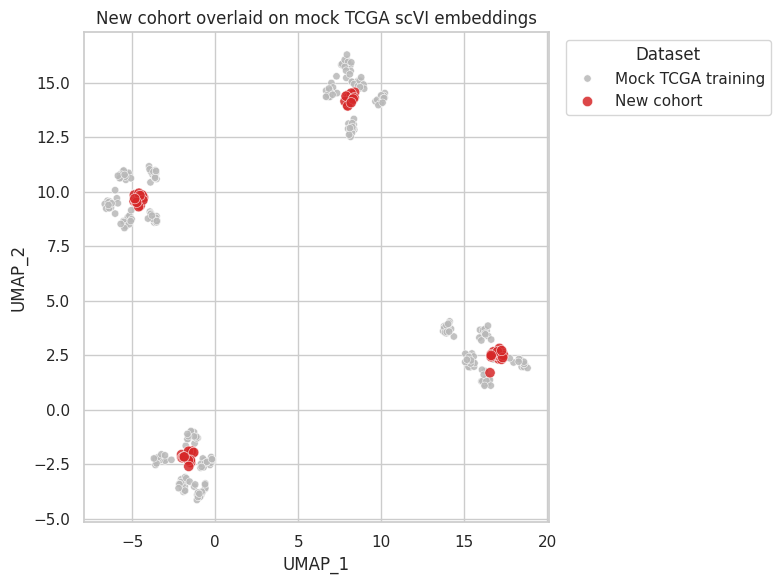

In [12]:
combined_embeddings = pd.concat([train_embeddings, test_embeddings], axis=0)
combined_group = pd.Series(
    ["Mock TCGA training"] * len(train_embeddings) + ["New cohort"] * len(test_embeddings),
    index=combined_embeddings.index,
    name="dataset",
)
combined_xy = umap.UMAP(
    n_neighbors=20, min_dist=0.25, metric="euclidean", random_state=RANDOM_STATE
).fit_transform(combined_embeddings)
combined_projection = pd.DataFrame(
    {"UMAP_1": combined_xy[:, 0], "UMAP_2": combined_xy[:, 1], "dataset": combined_group},
    index=combined_embeddings.index,
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=combined_projection,
    x="UMAP_1",
    y="UMAP_2",
    hue="dataset",
    hue_order=["Mock TCGA training", "New cohort"],
    palette={"Mock TCGA training": "#B8B8B8", "New cohort": "#D62728"},
    size="dataset",
    sizes={"Mock TCGA training": 28, "New cohort": 55},
    alpha=0.85,
)
plt.title("New cohort overlaid on mock TCGA scVI embeddings")
plt.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. UMAP of unseen embeddings colored by predicted TME subtype

We retain the test-sample coordinates from the joint projection above, which makes this view directly comparable with the overlay.

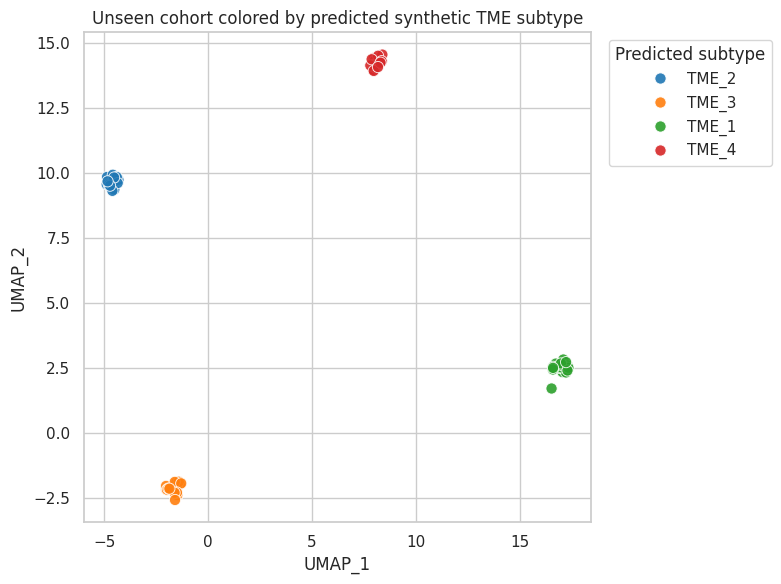

In [13]:
test_projection = combined_projection.loc[test_embeddings.index, ["UMAP_1", "UMAP_2"]].copy()
test_projection["predicted_subtype"] = test_predictions.loc[
    test_projection.index, "predicted_subtype"
]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=test_projection,
    x="UMAP_1",
    y="UMAP_2",
    hue="predicted_subtype",
    palette="tab10",
    s=65,
    alpha=0.9,
)
plt.title("Unseen cohort colored by predicted synthetic TME subtype")
plt.legend(title="Predicted subtype", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Next steps

When approved real data become available, replace the cohort CSVs and label file while preserving the documented samples-by-genes schema. Before scientific use, validate scVI's applicability to bulk counts, feature identifiers, correction strength, biological-signal preservation, and generalization on genuinely held-out cohorts.